In [3]:
# Cell 1 - Imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_ANALYTICS, BQ_CLUSTERING_TRACTS

In [4]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_CLUSTERING_TRACTS}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df = client.query(query).to_arrow().to_pandas()
tract_df.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83313 non-null  float64
 6   builder_developer_count             83313 non-null  float64
 7   landuse_change_count                83313 non-null  float64
 8   building_permit_count               83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  pre_early_dev_parcels_bin           83313 non-null  

In [5]:
# NA treatment — same as clustering notebook
tract_df['pre_early_dev_parcels'] = tract_df['pre_early_dev_parcels'].fillna(0)
tract_df['builder_developer_count'] = tract_df['builder_developer_count'].fillna(0)
tract_df['building_permit_count'] = tract_df['building_permit_count'].fillna(0)
tract_df['landuse_change_count'] = tract_df['landuse_change_count'].fillna(0)
tract_df['cable_penetration'] = tract_df['cable_penetration'].fillna(0)
tract_df['fiber_opportunity_gap'] = tract_df['fiber_opportunity_gap'].fillna(1.0)

fiber_dist_cap = tract_df['median_dist_nearest_fiber_m'].quantile(0.99)
tract_df['median_dist_nearest_fiber_m'] = tract_df['median_dist_nearest_fiber_m'].fillna(fiber_dist_cap)

hotspot_cap = tract_df['median_dist_nearest_hotspot'].max() * 1.25
tract_df['median_dist_nearest_hotspot'] = tract_df['median_dist_nearest_hotspot'].fillna(hotspot_cap)

# Drop columns not used as features
cols_to_drop = [col for col in tract_df.columns 
                if col in ['tract_geoid', 'estimated_fcc_units', 'provider_competitive_landscape', 'cable_future_gap', 'cluster']
                or col.endswith('_bin')]

y = tract_df['cluster']
X = tract_df.drop(columns=cols_to_drop)

feature_cols = X.columns.tolist()
print(f"Target classes: {sorted(y.unique())}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Features (13): ['pop_ch_avg', 'pop_pctch_avg', 'estimated_census_housing_units', 'pre_early_dev_parcels', 'builder_developer_count', 'landuse_change_count', 'building_permit_count', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'cable_penetration', 'fiber_opportunity_gap', 'fiber_speed_top_tier', 'provider_competitive_landscape_ord']
X shape: (83313, 13), y shape: (83313,)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      3071
           1       0.96      0.94      0.95      1264
           2       0.93      0.92      0.93      1476
           3       0.93      0.95      0.94      3351
           4       0.94      0.95      0.94      2096
           5       0.97      0.94      0.96       823
           6       0.91      0.92      0.92      2742
           7       0.95      0.92      0.94      1840

    accuracy                           0.94     16663
   macro avg       0.94      0.94      0.94     16663
weighted avg       0.94      0.94      0.94     16663



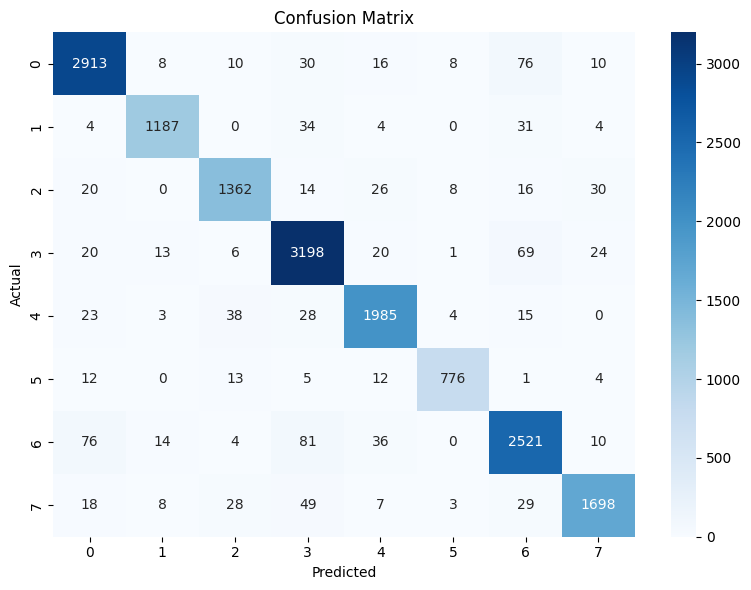

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()

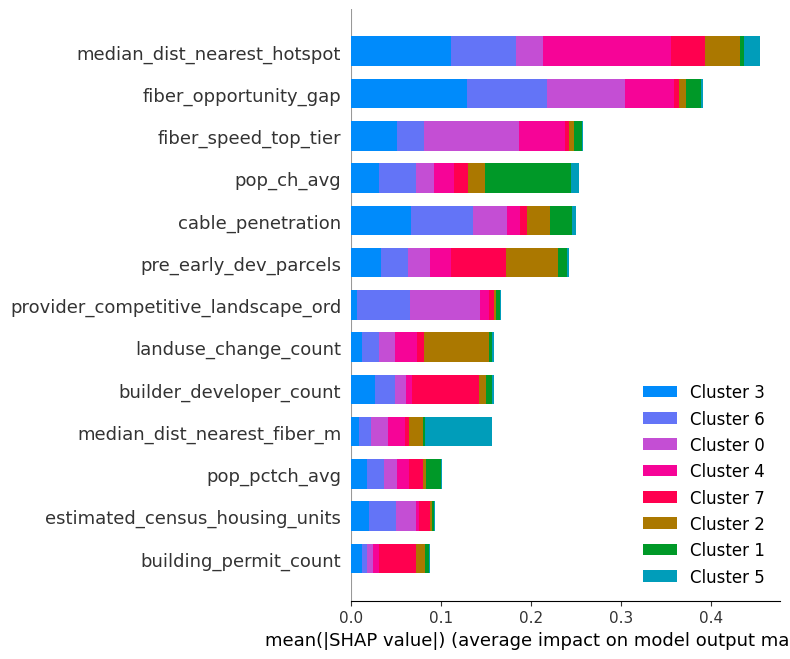

In [7]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Global feature importance (mean |SHAP| across all classes)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", class_names=[f"Cluster {i}" for i in sorted(y.unique())])

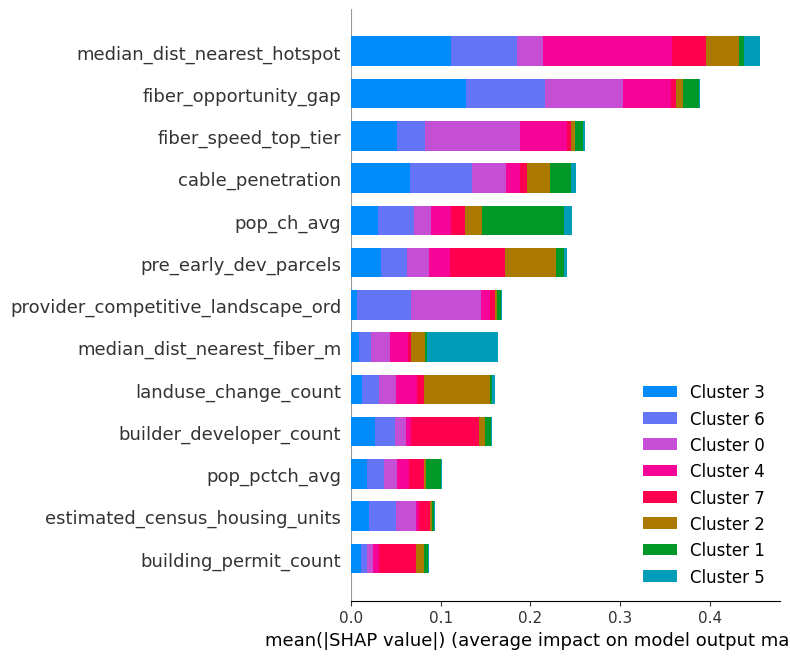

In [6]:
import shap

# Subsample for SHAP — full test set is unnecessarily slow
X_shap = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

# Global feature importance (mean |SHAP| across all classes)
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar",
                  class_names=[f"Cluster {i}" for i in sorted(y.unique())])

In [ ]:
# NOTE: Temporary measure to save shap outputs because of jupyter render issues
import joblib

joblib.dump(shap_values, 'data/shap_values_k8.joblib')
joblib.dump(X_shap, 'data/X_shap_k8.joblib')
print(f"Saved shap_values shape: {shap_values.shape}, X_shap shape: {X_shap.shape}")

In [8]:
import joblib

shap_values = joblib.load('data/shap_values_k8.joblib')
X_shap = joblib.load('data/X_shap_k8.joblib')
print(f"Loaded shap_values shape: {shap_values.shape}, X_shap shape: {X_shap.shape}")

Loaded shap_values shape: (2000, 13, 8), X_shap shape: (2000, 13)



--- Cluster 0 — Top features by mean |SHAP| ---
fiber_speed_top_tier                  0.1063
fiber_opportunity_gap                 0.0870
provider_competitive_landscape_ord    0.0784
cable_penetration                     0.0384
median_dist_nearest_hotspot           0.0293
pre_early_dev_parcels                 0.0247
estimated_census_housing_units        0.0220
median_dist_nearest_fiber_m           0.0206
pop_ch_avg                            0.0197
landuse_change_count                  0.0184
pop_pctch_avg                         0.0147
builder_developer_count               0.0122
building_permit_count                 0.0070



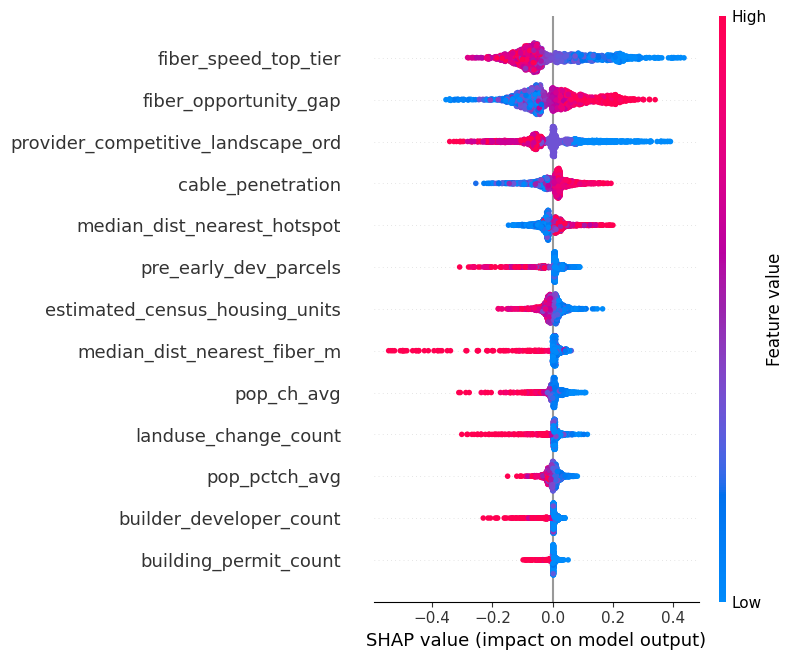


--- Cluster 1 — Top features by mean |SHAP| ---
pop_ch_avg                            0.0911
cable_penetration                     0.0243
fiber_opportunity_gap                 0.0171
pop_pctch_avg                         0.0167
pre_early_dev_parcels                 0.0091
fiber_speed_top_tier                  0.0089
builder_developer_count               0.0069
median_dist_nearest_hotspot           0.0045
building_permit_count                 0.0041
provider_competitive_landscape_ord    0.0040
landuse_change_count                  0.0031
estimated_census_housing_units        0.0024
median_dist_nearest_fiber_m           0.0023



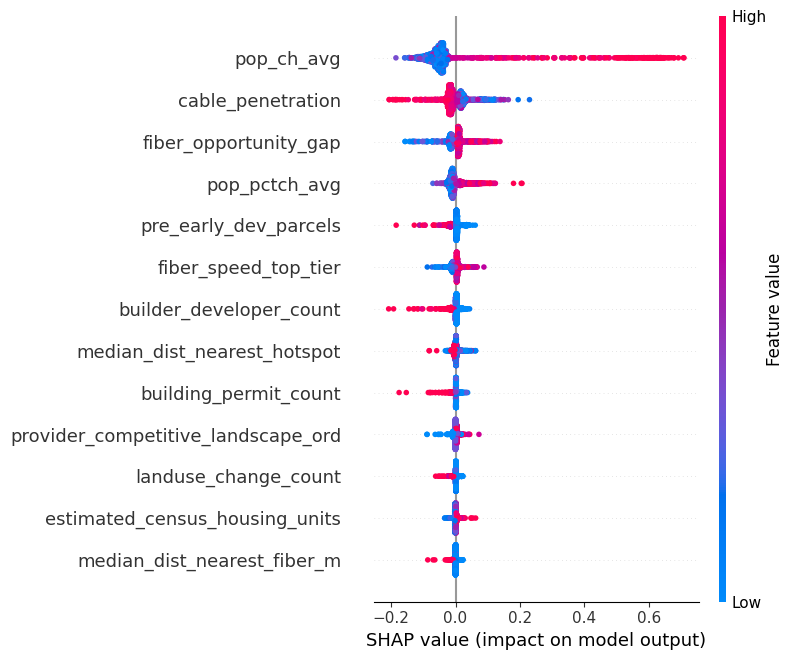


--- Cluster 2 — Top features by mean |SHAP| ---
landuse_change_count                  0.0731
pre_early_dev_parcels                 0.0575
median_dist_nearest_hotspot           0.0378
cable_penetration                     0.0258
pop_ch_avg                            0.0196
median_dist_nearest_fiber_m           0.0155
building_permit_count                 0.0092
fiber_opportunity_gap                 0.0083
builder_developer_count               0.0071
fiber_speed_top_tier                  0.0049
pop_pctch_avg                         0.0030
provider_competitive_landscape_ord    0.0026
estimated_census_housing_units        0.0023



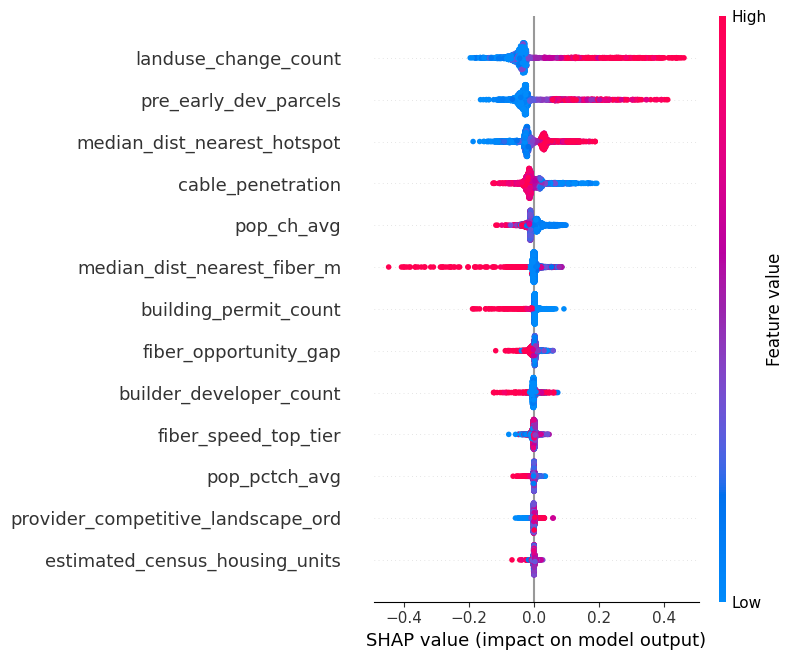


--- Cluster 3 — Top features by mean |SHAP| ---
fiber_opportunity_gap                 0.1279
median_dist_nearest_hotspot           0.1115
cable_penetration                     0.0661
fiber_speed_top_tier                  0.0518
pre_early_dev_parcels                 0.0330
pop_ch_avg                            0.0305
builder_developer_count               0.0266
estimated_census_housing_units        0.0197
pop_pctch_avg                         0.0178
landuse_change_count                  0.0123
building_permit_count                 0.0117
median_dist_nearest_fiber_m           0.0089
provider_competitive_landscape_ord    0.0067



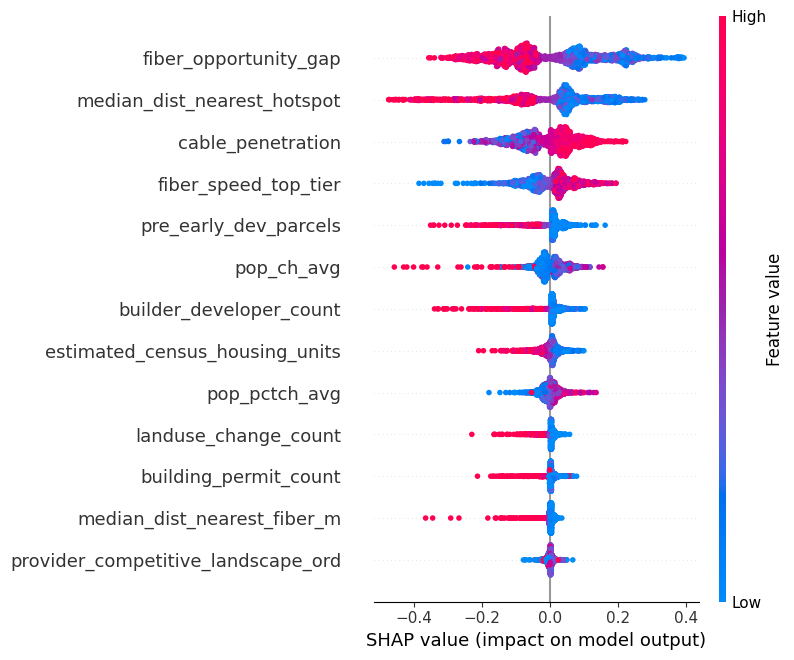


--- Cluster 4 — Top features by mean |SHAP| ---
median_dist_nearest_hotspot           0.1439
fiber_opportunity_gap                 0.0542
fiber_speed_top_tier                  0.0521
landuse_change_count                  0.0242
pre_early_dev_parcels                 0.0234
pop_ch_avg                            0.0219
median_dist_nearest_fiber_m           0.0205
cable_penetration                     0.0146
pop_pctch_avg                         0.0133
provider_competitive_landscape_ord    0.0101
building_permit_count                 0.0067
builder_developer_count               0.0063
estimated_census_housing_units        0.0031



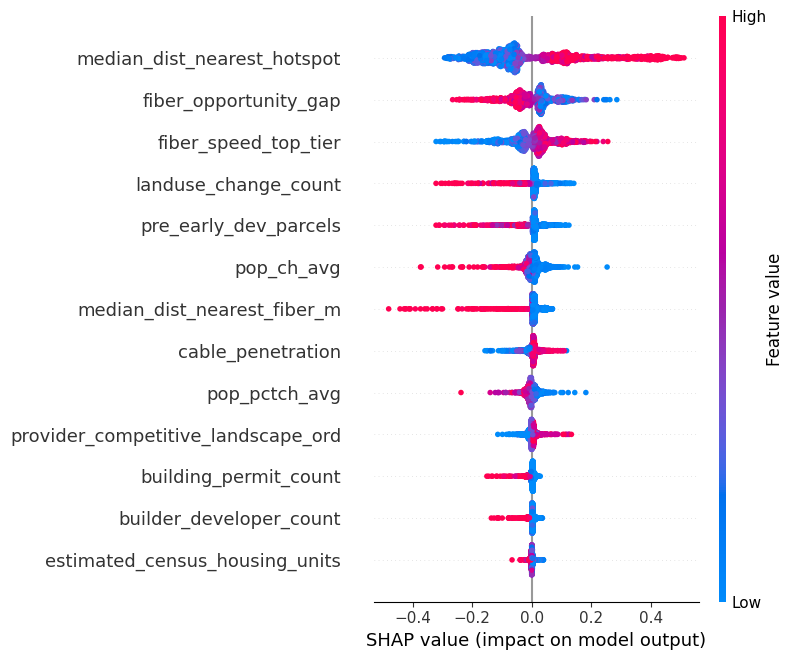


--- Cluster 5 — Top features by mean |SHAP| ---
median_dist_nearest_fiber_m           0.0786
median_dist_nearest_hotspot           0.0179
pop_ch_avg                            0.0088
cable_penetration                     0.0048
pre_early_dev_parcels                 0.0033
landuse_change_count                  0.0025
provider_competitive_landscape_ord    0.0018
fiber_opportunity_gap                 0.0016
builder_developer_count               0.0015
fiber_speed_top_tier                  0.0015
pop_pctch_avg                         0.0013
building_permit_count                 0.0009
estimated_census_housing_units        0.0008



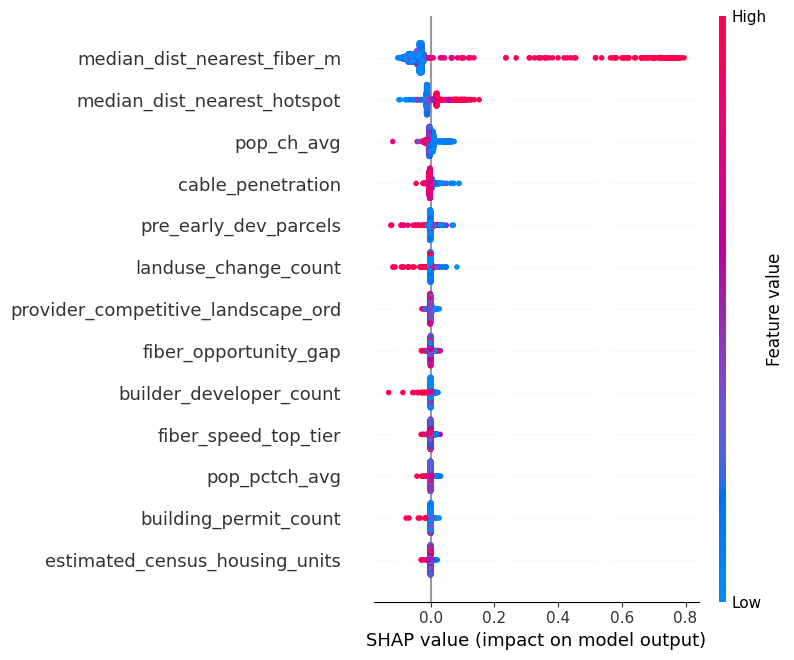


--- Cluster 6 — Top features by mean |SHAP| ---
fiber_opportunity_gap                 0.0880
median_dist_nearest_hotspot           0.0734
cable_penetration                     0.0689
provider_competitive_landscape_ord    0.0598
pop_ch_avg                            0.0394
estimated_census_housing_units        0.0310
fiber_speed_top_tier                  0.0303
pre_early_dev_parcels                 0.0292
builder_developer_count               0.0223
landuse_change_count                  0.0191
pop_pctch_avg                         0.0190
median_dist_nearest_fiber_m           0.0136
building_permit_count                 0.0059



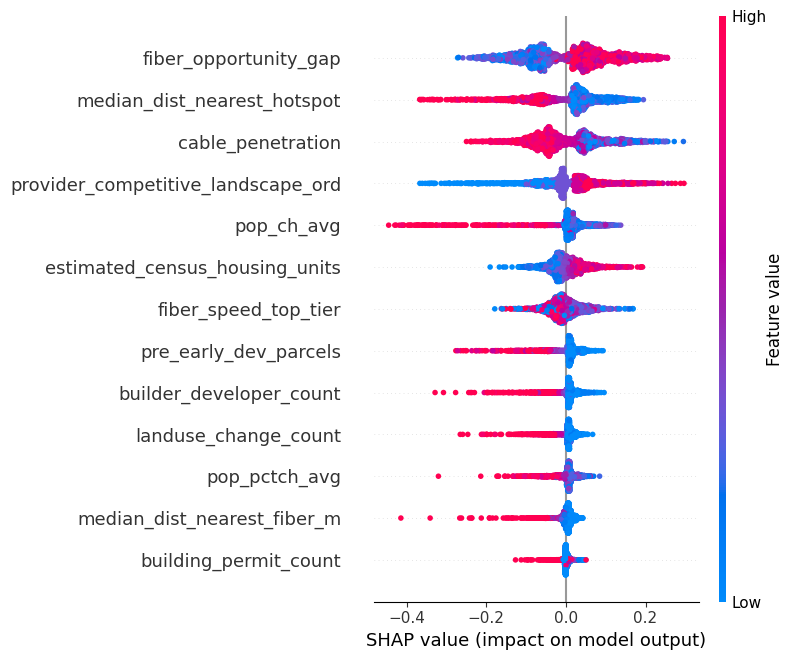


--- Cluster 7 — Top features by mean |SHAP| ---
builder_developer_count               0.0748
pre_early_dev_parcels                 0.0609
building_permit_count                 0.0410
median_dist_nearest_hotspot           0.0374
pop_pctch_avg                         0.0162
pop_ch_avg                            0.0153
estimated_census_housing_units        0.0119
cable_penetration                     0.0078
landuse_change_count                  0.0076
provider_competitive_landscape_ord    0.0052
fiber_opportunity_gap                 0.0051
fiber_speed_top_tier                  0.0049
median_dist_nearest_fiber_m           0.0039



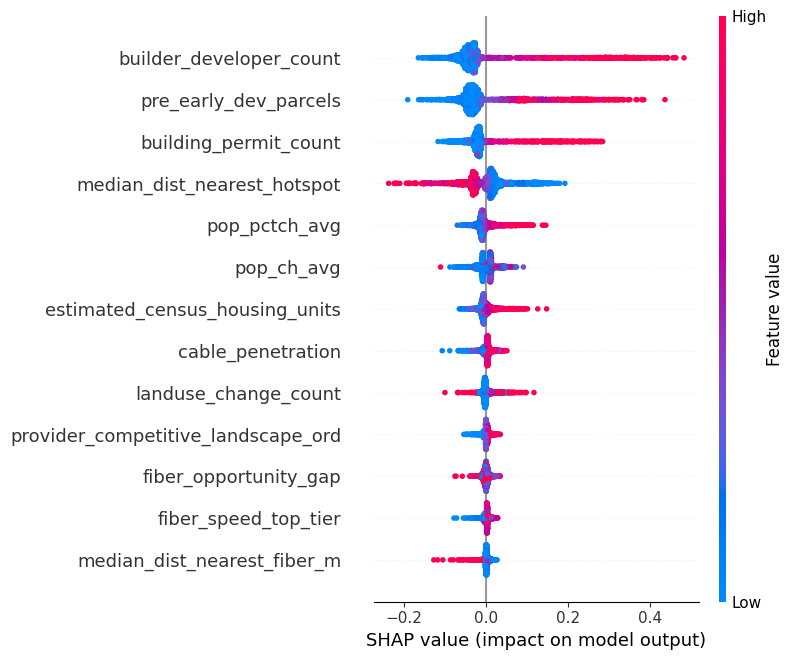

In [10]:
import shap
cluster_labels_sorted = sorted(y.unique())

# Convert 3D array (samples, features, classes) to list of per-class arrays
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_by_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_by_class = shap_values

for idx, cluster_id in enumerate(cluster_labels_sorted):
    mean_abs_shap = np.abs(shap_by_class[idx]).mean(axis=0)
    importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
    print(f"\n--- Cluster {cluster_id} — Top features by mean |SHAP| ---")
    print(importance.round(4).to_string())
    print()

    shap.summary_plot(shap_by_class[idx], X_shap, feature_names=feature_cols, 
                      title=f"Cluster {cluster_id}", show=True)

In [13]:
# Per-cluster importance table
shap_importance = pd.DataFrame(
    {f"Cluster {c}": np.abs(shap_by_class[i]).mean(axis=0) 
     for i, c in enumerate(cluster_labels_sorted)},
    index=feature_cols
)
shap_importance['global_sum'] = shap_importance.sum(axis=1)
shap_importance['global_mean'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values(by='global_sum', ascending=False)

with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4f}'.format):
    print("\n\n--- SHAP Importance sorted by sum---")
    print(shap_importance.to_string())

# Grand mean: mean |SHAP| across all samples and classes simultaneously
grand_mean = pd.Series(
    np.abs(shap_values).mean(axis=(0, 2)),
    index=feature_cols,
    name='grand_mean_abs_shap'
).sort_values(ascending=False)

print("\n\n--- Global importance: mean |SHAP| across all samples × clusters ---")
print(grand_mean.round(4).to_string())



--- SHAP Importance sorted by sum---
                                    Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7  global_sum  global_mean
median_dist_nearest_hotspot            0.0293     0.0045     0.0378     0.1115     0.1439     0.0179     0.0734     0.0374      0.4556       0.1013
fiber_opportunity_gap                  0.0870     0.0171     0.0083     0.1279     0.0542     0.0016     0.0880     0.0051      0.3892       0.0865
fiber_speed_top_tier                   0.1063     0.0089     0.0049     0.0518     0.0521     0.0015     0.0303     0.0049      0.2607       0.0579
cable_penetration                      0.0384     0.0243     0.0258     0.0661     0.0146     0.0048     0.0689     0.0078      0.2506       0.0557
pop_ch_avg                             0.0197     0.0911     0.0196     0.0305     0.0219     0.0088     0.0394     0.0153      0.2463       0.0547
pre_early_dev_parcels                  0.0247     0.0091     0.0575     0

#### Index Construction — Method 1: Independent Overall

**Step 1 — Raw SHAP weights (13 features):**
Mean |SHAP| across all samples and clusters per feature:
$$\text{raw\_shap}_i = \frac{1}{N \times K} \sum_{n=1}^{N} \sum_{k=1}^{K} |\text{SHAP}_{n,i,k}|$$

**Step 2 — Individual feature weights (13), normalized to sum = 1:**
$$w_i = \frac{\text{raw\_shap}_i}{\sum_{j=1}^{13} \text{raw\_shap}_j}$$
Used for the overall index.

**Step 3 — Bucket-normalized feature weights (13), each group sums to 1:**
$$w_i^{\text{group}} = \frac{\text{raw\_shap}_i}{\sum_{j \in \text{group}} \text{raw\_shap}_j}$$
Used for sub-indices (growth/FCC/demo).

**Step 4 — Sub-index scores (3 per tract: growth, FCC, demo):**
For each tract and each group:
1. Min-max scale each feature to [0, 1]: $v_i^{\text{scaled}} = \frac{v_i - \min(v_i)}{\max(v_i) - \min(v_i)}$
2. Invert distance features: $v_i^{\text{scaled}} = 1 - v_i^{\text{scaled}}$ for distances (closer = better)
3. Weighted sum: $\text{idx\_group\_raw} = \sum_{i \in \text{group}} w_i^{\text{group}} \times v_i^{\text{scaled}}$
4. Rescale to 0–100: $\text{idx\_group} = \frac{\text{idx\_group\_raw} - \min(\text{raw})}{\max(\text{raw}) - \min(\text{raw})} \times 100$

**Step 5 — Overall index score (1 per tract):**
Same as step 4 but across all 13 features using individual weights from step 2:
$$\text{idx\_overall\_raw} = \sum_{i=1}^{13} w_i \times v_i^{\text{scaled}}$$
Rescaled to 0–100.

**Note:** Sub-indices and overall are computed independently — overall ≠ f(growth, FCC, demo). The within-group normalization (step 3) and global normalization (step 2) produce different weights for the same feature.

**Scaling caveat:** Min-max scaling is sensitive to outliers and skewed distributions. Distance to growth hotspot captures ~59% of variance in the overall index due to its bimodal distribution (26% of tracts had NA → filled at 1.25× max). Rank-based scaling compresses this to ~29%.

In [41]:
from sklearn.preprocessing import MinMaxScaler

# Feature groups
growth_features = [
    'pre_early_dev_parcels',
    'builder_developer_count',
    'landuse_change_count',
    'building_permit_count',
    'median_dist_nearest_hotspot'
]
fcc_features = [
    'cable_penetration',
    'fiber_opportunity_gap',
    'fiber_speed_top_tier',
    'median_dist_nearest_fiber_m',
    'provider_competitive_landscape_ord'
]
demo_features = [
    'pop_ch_avg',
    'pop_pctch_avg',
    'estimated_census_housing_units'
]

inverse_features = [
    'median_dist_nearest_hotspot',
    'median_dist_nearest_fiber_m',
    'cable_penetration',
    'fiber_speed_top_tier',
    'provider_competitive_landscape_ord'
    ]

# Grand-mean SHAP weights
shap_weights = pd.Series(np.abs(shap_values).mean(axis=(0, 2)), index=feature_cols)

def shap_weighted_index(df, features, weights):
    group_weights = weights[features]
    group_weights = group_weights / group_weights.sum()
    scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df[features]),
        columns=features, index=df.index
    )
    for col in inverse_features:
        if col in scaled.columns:
            scaled[col] = 1 - scaled[col]
    return (scaled * group_weights).sum(axis=1)

# Build sub-indices
tract_df['idx_growth_raw'] = shap_weighted_index(tract_df, growth_features, shap_weights)
tract_df['idx_fcc_raw'] = shap_weighted_index(tract_df, fcc_features, shap_weights)
tract_df['idx_demo_raw'] = shap_weighted_index(tract_df, demo_features, shap_weights)
tract_df['idx_overall_raw'] = shap_weighted_index(tract_df, feature_cols, shap_weights)

# Scale all to 0-100
for idx_col in ['idx_growth_raw', 'idx_fcc_raw', 'idx_demo_raw', 'idx_overall_raw']:
    col_out = idx_col.replace('_raw', '')
    tract_df[col_out] = (
        MinMaxScaler(feature_range=(0, 100))
        .fit_transform(tract_df[[idx_col]])
        .flatten().round(2)
    )

# --- Print all weights ---
# 1. Per-feature weights within each group
print("=" * 60)
print("NORMALIZED WEIGHTS PER GROUP (min-max scaling)")
print("=" * 60)
for name, features in [('Growth', growth_features), ('FCC', fcc_features), ('Demo', demo_features)]:
    w = shap_weights[features]
    w_norm = (w / w.sum()).round(3)
    print(f"\n{name}:")
    print(w_norm.to_string())

# 2. Overall feature weights (across all 13)
print("\n" + "=" * 60)
print("OVERALL FEATURE WEIGHTS (all 13 features)")
print("=" * 60)
overall_weights = (shap_weights / shap_weights.sum()).round(3).sort_values(ascending=False)
print(overall_weights.to_string())

# 3. Index summary stats
idx_cols = ['idx_growth', 'idx_fcc', 'idx_demo', 'idx_overall']
print("\n" + "=" * 60)
print("INDEX SUMMARY")
print("=" * 60)
print(tract_df[idx_cols].describe().round(2).to_string())

# 4. Correlations
print("\n" + "=" * 60)
print("CORRELATION BETWEEN SUB-INDICES AND OVERALL")
print("=" * 60)
print(tract_df[idx_cols].corr(method='spearman').round(3).to_string())

NORMALIZED WEIGHTS PER GROUP (min-max scaling)

Growth:
pre_early_dev_parcels          0.219
builder_developer_count        0.143
landuse_change_count           0.145
building_permit_count          0.079
median_dist_nearest_hotspot    0.414

FCC:
cable_penetration                     0.203
fiber_opportunity_gap                 0.316
fiber_speed_top_tier                  0.211
median_dist_nearest_fiber_m           0.133
provider_competitive_landscape_ord    0.137

Demo:
pop_ch_avg                        0.558
pop_pctch_avg                     0.231
estimated_census_housing_units    0.211

OVERALL FEATURE WEIGHTS (all 13 features)
median_dist_nearest_hotspot           0.164
fiber_opportunity_gap                 0.140
fiber_speed_top_tier                  0.094
cable_penetration                     0.090
pop_ch_avg                            0.089
pre_early_dev_parcels                 0.087
provider_competitive_landscape_ord    0.061
median_dist_nearest_fiber_m           0.059
landuse_cha

In [42]:
# Check variance contribution of each feature to overall index
scaled = pd.DataFrame(MinMaxScaler().fit_transform(tract_df[feature_cols]), columns=feature_cols, index=tract_df.index)
for col in inverse_features:
    scaled[col] = 1 - scaled[col]

weights_norm = shap_weights / shap_weights.sum()
weighted_features = scaled * weights_norm

print("Variance contribution per feature to overall index:")
var_contrib = weighted_features.var().sort_values(ascending=False)
print((var_contrib / var_contrib.sum() * 100).round(2).to_string())

Variance contribution per feature to overall index:
median_dist_nearest_hotspot           58.96
pre_early_dev_parcels                 12.79
fiber_speed_top_tier                  10.74
landuse_change_count                   5.48
builder_developer_count                5.29
provider_competitive_landscape_ord     1.83
median_dist_nearest_fiber_m            1.68
building_permit_count                  1.62
fiber_opportunity_gap                  1.08
cable_penetration                      0.45
estimated_census_housing_units         0.04
pop_pctch_avg                          0.03
pop_ch_avg                             0.01


In [43]:
# Clean up: drop rank-based and raw columns
cols_to_remove = [c for c in tract_df.columns if 'rank' in c or c.endswith('_raw')]
tract_df.drop(columns=cols_to_remove, inplace=True, errors='ignore')
print(f"Dropped {len(cols_to_remove)} columns. Remaining: {tract_df.shape[1]}")
print(tract_df.info())

Dropped 4 columns. Remaining: 27
<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83313 non-null  float64
 6   builder_developer_count             83313 non-null  float64
 7   landuse_change_count                83313 non-null  float64
 8   building_permit_count               83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  pre_early_dev_parce

##### Weighted Average Approach

#### Index Construction — Method 2: Weighted Average Overall

Steps 1–4 are identical to Method 1 (same sub-indices).

**Step 5 — Group weights (3 groups):**
Each group's share of total raw SHAP:
$$W_{\text{group}} = \frac{\sum_{i \in \text{group}} \text{raw\_shap}_i}{\sum_{j=1}^{13} \text{raw\_shap}_j}$$

| Group  | Weight |
|--------|--------|
| Growth | 0.40   |
| FCC    | 0.44   |
| Demo   | 0.16   |

**Step 6 — Overall index as weighted average of sub-indices:**
$$\text{idx\_overall\_wa} = W_{\text{growth}} \times \text{idx\_growth} + W_{\text{fcc}} \times \text{idx\_fcc} + W_{\text{demo}} \times \text{idx\_demo}$$

**Key difference from Method 1:** The overall is fully decomposable — each tract's score can be explained as "40% growth + 44% FCC + 16% demographic." Variance dominance by a single feature is contained within its sub-index before contributing to the overall.

In [44]:
# Alternative: Overall = weighted average of sub-indices 
# Group weights = each group's share of total raw SHAP
group_shap = {
    'Growth': shap_weights[growth_features].sum(),
    'FCC': shap_weights[fcc_features].sum(),
    'Demo': shap_weights[demo_features].sum()
}
total_shap = sum(group_shap.values())
group_weights = {k: v / total_shap for k, v in group_shap.items()}

print("=" * 60)
print("GROUP WEIGHTS FOR WEIGHTED AVERAGE OVERALL INDEX")
print("=" * 60)
for k, v in group_weights.items():
    print(f"  {k}: {v:.3f}")

# Compute overall as weighted average of sub-indices
tract_df['idx_overall_wa'] = (
    group_weights['Growth'] * tract_df['idx_growth'] +
    group_weights['FCC'] * tract_df['idx_fcc'] +
    group_weights['Demo'] * tract_df['idx_demo']
).round(2)

# Compare both overall indices
idx_cols_compare = ['idx_growth', 'idx_fcc', 'idx_demo', 'idx_overall', 'idx_overall_wa']
print("\n" + "=" * 60)
print("INDEX SUMMARY (with weighted average overall)")
print("=" * 60)
print(tract_df[idx_cols_compare].describe().round(2).to_string())

print("\n" + "=" * 60)
print("CORRELATIONS (with weighted average overall)")
print("=" * 60)
print(tract_df[idx_cols_compare].corr(method='spearman').round(3).to_string())

print("\n" + "=" * 60)
print("CORRELATION BETWEEN TWO OVERALL METHODS")
print("=" * 60)
print(f"  Pearson:  {tract_df['idx_overall'].corr(tract_df['idx_overall_wa']):.3f}")
print(f"  Spearman: {tract_df['idx_overall'].corr(tract_df['idx_overall_wa'], method='spearman'):.3f}")

GROUP WEIGHTS FOR WEIGHTED AVERAGE OVERALL INDEX
  Growth: 0.397
  FCC: 0.444
  Demo: 0.159

INDEX SUMMARY (with weighted average overall)
       idx_growth   idx_fcc  idx_demo  idx_overall  idx_overall_wa
count    83313.00  83313.00  83313.00     83313.00        83313.00
mean        35.13     67.74     10.26        44.17           45.66
std         21.57     10.85      2.07        15.01            9.51
min          0.00      0.00      0.00         0.00           15.46
25%         21.01     59.67      8.89        34.45           39.64
50%         35.78     67.58      9.97        44.22           45.64
75%         45.08     75.86     11.30        52.83           51.43
max        100.00    100.00    100.00       100.00           81.76

CORRELATIONS (with weighted average overall)
                idx_growth  idx_fcc  idx_demo  idx_overall  idx_overall_wa
idx_growth           1.000   -0.093     0.388        0.884           0.836
idx_fcc             -0.093    1.000    -0.132        0.331    

In [45]:
tract_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83313 non-null  float64
 6   builder_developer_count             83313 non-null  float64
 7   landuse_change_count                83313 non-null  float64
 8   building_permit_count               83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  pre_early_dev_parcels_bin           83313 non-null  

In [46]:
# Cell 10 - Upload tract_df_final to BQ (teu_analytics dataset)
# TODO: Update table_id = f"{GCS_PROJECT_ID}.teu_analytics.indexed_tracts"


client = bigquery.Client(project=GCS_PROJECT_ID)
table_id = f"{GCS_PROJECT_ID}.teu_analytics.indexed_tracts_v1"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

job = client.load_table_from_dataframe(tract_df, table_id, job_config=job_config)
job.result()

print(f"Uploaded {job.output_rows} rows to {table_id}")

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 83313 rows to clgx-gis-app-dev-06e3.teu_analytics.indexed_tracts_v1


In [ ]:
-- Additional logic in BQ
CREATE OR REPLACE VIEW `clgx-gis-app-dev-06e3.teu_analytics.indexed_tracts_v1_with_geo` AS 
SELECT
  LEFT(a.tract_geoid,2) AS state_code,
  a.tract_geoid,
  a.cluster,
  a.idx_growth,
  a.idx_fcc,
  a.idx_demo,
  a.idx_overall,
  a.idx_overall_wa AS idx_overall_weighted,
  b.geometry
FROM `clgx-gis-app-dev-06e3.teu_analytics.indexed_tracts_v1` a
JOIN `clgx-gis-app-dev-06e3.teu_features.all_features_tract` b 
ON a.tract_geoid = b.tract_geoid;